## Introduction

This lab provides a hands-on exploration of K-Means clustering, a fundamental unsupervised machine learning algorithm. We will apply K-Means to both synthetic and real-world datasets, demonstrating its core principles and practical applications. The lab also introduces the concept of machine learning pipelines for streamlined workflow management.

## Goal and Purpose

The primary goal of this lab is to solidify understanding of K-Means clustering through practical implementation. By the end of this lab, you will be able to:

*   Generate and visualize synthetic datasets suitable for clustering.
*   Implement and apply the K-Means algorithm to group data points into clusters.
*   Evaluate clustering performance using metrics like WCSS (Within-Cluster Sum of Squares) and Silhouette Score.
*   Determine the optimal number of clusters (`k`) for a given dataset.
*   Utilize scikit-learn pipelines to build robust and reproducible machine learning workflows.
*   Apply clustering techniques to real-world datasets (e.g., California Housing and US Arrests data) to extract meaningful insights.

This notebook serves as a demonstration of fundamental machine learning concepts and practical coding skills in data analysis and unsupervised learning.

## ML Concepts Used

*   **Unsupervised Learning:** Learning patterns from data without explicit labels.
*   **Clustering:** Grouping a set of objects in such a way that objects in the same group (cluster) are more similar to each other than to those in other groups.
*   **K-Means Clustering:** An iterative algorithm that partitions `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid).
*   **Centroids:** The geometric center of a cluster.
*   **Inertia (WCSS - Within-Cluster Sum of Squares):** A measure of how internally coherent clusters are. Lower WCSS generally indicates better clustering.
*   **Silhouette Score:** A metric used to calculate the goodness of a clustering technique. Its value ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
*   **Elbow Method:** A heuristic method for determining the number of clusters in a dataset by looking at the plot of WCSS vs. number of clusters.
*   **Machine Learning Pipelines:** A sequence of data processing components and machine learning models that can be executed together to automate a workflow.
*   **Data Scaling/Normalization:** Preprocessing technique to standardize the range of independent variables or features of the data.

## Generate Synthetic Dataset Suitable For Clustering

To begin, we will create a synthetic 2-dimensional dataset using `make_blobs` from `sklearn.datasets`. This allows us to have a ground truth for the number of clusters, which is helpful for understanding and evaluating the K-Means algorithm. We will then visualize this dataset.

### Loading Libraries and Setting up Synthetic Data Generation

This cell imports all the necessary libraries for data manipulation, visualization, and machine learning tasks in this notebook. It then configures parameters for generating our synthetic dataset.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

This cell generates a 2D synthetic dataset with 3 distinct clusters using `make_blobs`. The `n_samples` parameter controls the total number of data points, `n_features` defines the dimensionality, and `random_state` ensures reproducibility.

In [10]:
n_samples = 500
random_state = 170

X, y = make_blobs(n_samples=n_samples, n_features=2,
                  centers=3, random_state=random_state)


This cell visualizes the generated 2D synthetic dataset using a scatter plot. Each point represents a data instance, and its position is determined by its two features. Since `make_blobs` creates distinct clusters, we expect to see three separate groupings of points.

<Axes: >

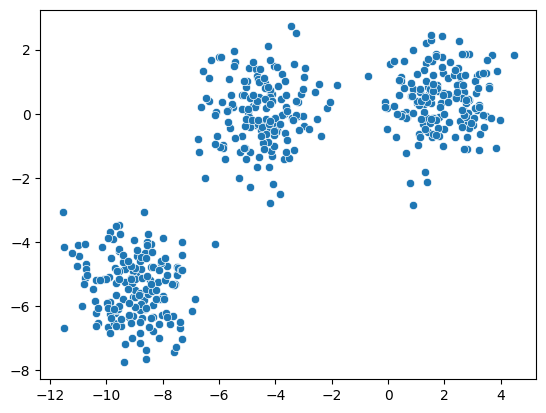

In [11]:
sns.scatterplot(x=X[:,0], y=X[:,1])

### Exercise: Generate and Visualize a 3D Synthetic Dataset

Your task is to extend the concept of synthetic data generation to three dimensions. Create a 3D dataset with three clusters and visualize it using a 3D scatter plot. This will demonstrate your ability to handle higher-dimensional data visualization.

Now, it's your turn to create a synthetic dataset of 3 dimensions consisting of three clusters. You will also need to visualize this data using a 3-D plot. You can use any suitable library.

Text(0.5, 0, 'Feature 3')

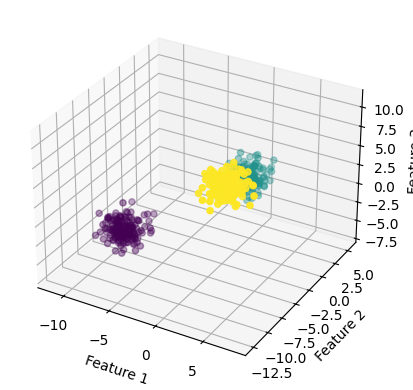

In [12]:
# TODO: Create a 3 feature dataset generated using 3 clusters and plot it.
from mpl_toolkits.mplot3d import Axes3D

n_samples = 500
n_features = 3
random_state = 170

X_3d, y_3d = make_blobs(n_samples=n_samples, n_features=n_features, centers=3, random_state=random_state)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y_3d)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

## Clustering using K-Means

Now that we have a clear understanding of our synthetic 2D dataset, we will apply the K-Means algorithm to cluster it. We'll start by initializing the K-Means model with a predetermined number of clusters, knowing the true number of clusters from our synthetic data generation.

This cell initializes the `KMeans` model. We specify `n_clusters` based on our knowledge of the synthetic data's true number of clusters (which is 3), set a `random_state` for reproducibility, and define `max_iter` for the maximum number of iterations the algorithm will run.

In [36]:
from sklearn.cluster import KMeans
predicted_clusters = 3 # need to play with this to get the correct value (3 was the best out of 2, 3, and 4)
max_iter = 100
random_state = 42

km = KMeans(n_clusters=predicted_clusters, random_state=random_state, max_iter=max_iter, n_init='auto')

This cell displays the K-Means model object, showing its initialized parameters. This is useful for verifying that the model has been set up as intended before fitting it to the data.

In [14]:
km

KMeans(max_iter=100, n_clusters=3, random_state=42)

This cell applies the K-Means algorithm to our synthetic dataset `X` using the `fit_predict` method. This method first fits the model to the data (i.e., finds the cluster centroids) and then predicts the cluster assignments for each data point. The `y_pred` variable will store the predicted cluster labels.

In [15]:
y_pred = km.fit_predict(X)

## Visualization of Clusters

To effectively compare the K-Means algorithm's performance, we'll visualize the actual clusters (ground truth) alongside the clusters predicted by our K-Means model. This side-by-side comparison will include the identified cluster centroids for the predicted data.

This cell generates two scatter plots side-by-side: one showing the original data colored by its true labels (`y`), and another showing the data colored by the K-Means predicted labels (`y_pred`). The predicted cluster centers (centroids) are also plotted on the 'Clustered Data' plot for clear visualization.

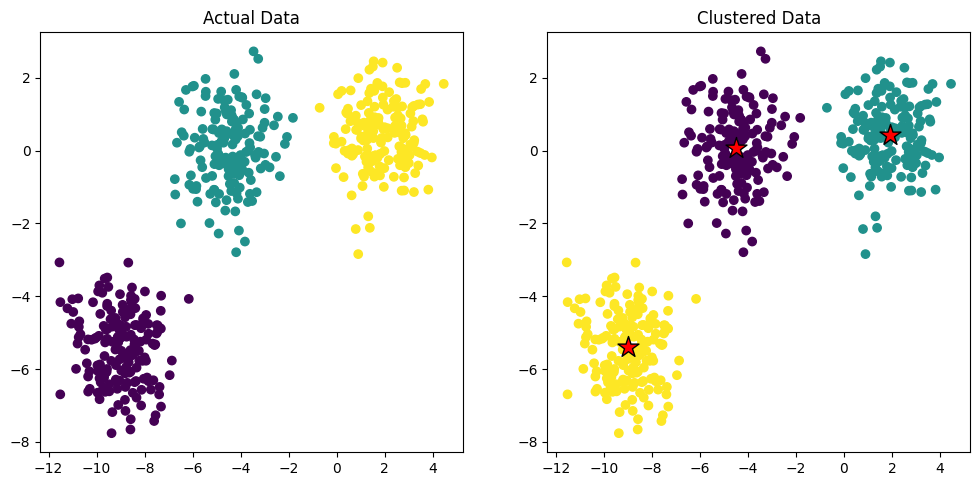

In [16]:


plt.figure(figsize=(12, 12))

plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Actual Data")

plt.subplot(222)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Clustered Data")

plt.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
    s=250, marker='*',
    c='red', edgecolor='black',
    label='centroids'
)

plt.show()

## WCSS and Silhouette Score

To quantitatively evaluate the quality of our K-Means clustering, we will compute two important metrics: Within-Cluster Sum of Squares (WCSS), also known as inertia, and the Silhouette Score. WCSS measures the compactness of clusters, while the Silhouette Score measures how similar an object is to its own cluster compared to other clusters.

In [17]:
km.inertia_

983.1843605401159

This cell calculates the Silhouette Score for the clustering. The Silhouette Score ranges from -1 to 1, where a higher value indicates better-defined clusters. A score close to 1 means the data points are well-matched to their own cluster and poorly matched to neighboring clusters.

In [18]:
silhouette_score(X, y_pred)

np.float64(0.7254535864779077)

## Finding Best Hyperparameters (Optimal `k`)

Determining the optimal number of clusters (`k`) is crucial for K-Means. We will explore various values of `k` and visualize the resulting clusters. Following this, we'll quantitatively assess each `k` using WCSS (Elbow Method) and Silhouette Scores to identify the most appropriate `k` for our dataset.

This cell iterates through different values of `k` (from 2 to 9) and applies K-Means clustering for each `k`. It then generates a scatter plot for each `k`, allowing for a visual inspection of how the clusters change with an increasing number of centroids. This preliminary visualization helps to intuitively understand the effect of `k`.

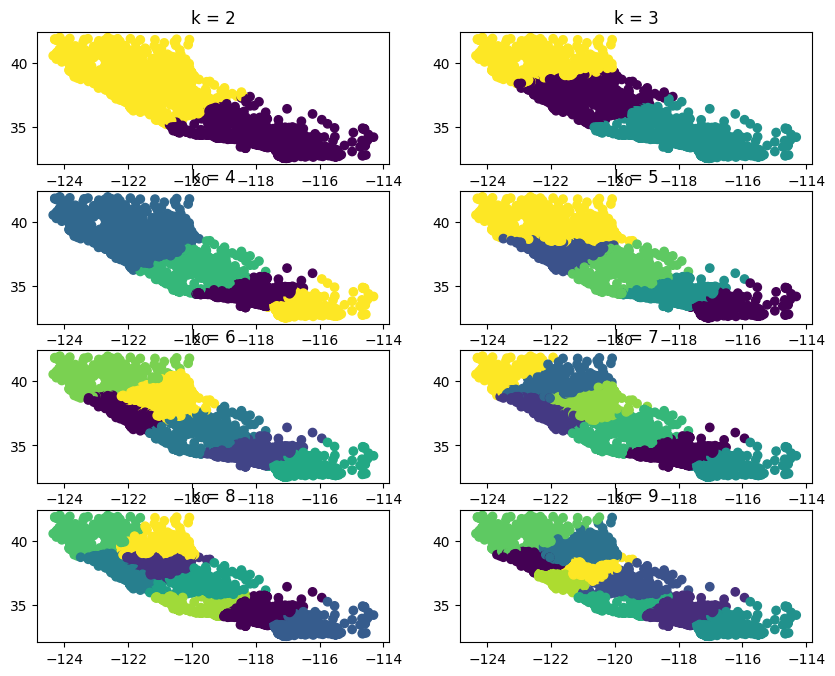

In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

plt.figure(figsize=(10, 10))

i = 1
for k in range(2, 10):
  km = KMeans(n_clusters=k, n_init='auto')
  y_pred = km.fit_predict(X)
  plt.subplot(5, 2, i)
  plt.scatter(X[:, 0], X[:, 1], c=y_pred)
  plt.title("k = " + str(k))
  i = i + 1

plt.show()

### Exercise: Evaluate WCSS and Silhouette Score for Different `k` Values

Now, your task is to systematically evaluate the K-Means clustering performance for a range of `k` values. You need to calculate both the WCSS and Silhouette Score for each `k` and then plot these metrics to identify the optimal number of clusters. Consider which `k` value provides the best balance between cluster compactness and separation.

This cell calculates the WCSS (inertia) and Silhouette Score for each `k` in the specified range (`k_values`). It stores these scores in lists, which will then be used for plotting to help determine the optimal `k`.

In [38]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Ensure `X`, `random_state`, and `max_iter` are defined if not in global scope due to out-of-order execution
# Assuming X is defined from Y7nP0TCcjIaA, and random_state, max_iter from Ei0EBlc3vHt8
# If this cell is run independently, X, random_state, max_iter would need re-definition.
# For now, re-use existing global values based on notebook structure.

k_values = range(2, 10)
wcss_scores = []
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=random_state, max_iter=max_iter, n_init='auto')
    y_pred = km.fit_predict(X)

    wcss = km.inertia_
    wcss_scores.append(wcss)
    silhouette_avg = silhouette_score(X, y_pred)
    silhouette_scores.append(silhouette_avg)

This cell generates two plots: one showing WCSS versus `k` (the 'Elbow Method' plot) and another showing the Silhouette Score versus `k`. These plots are critical for determining the optimal number of clusters, where the 'elbow' in the WCSS plot and the peak in the Silhouette Score plot often indicate a good `k`.

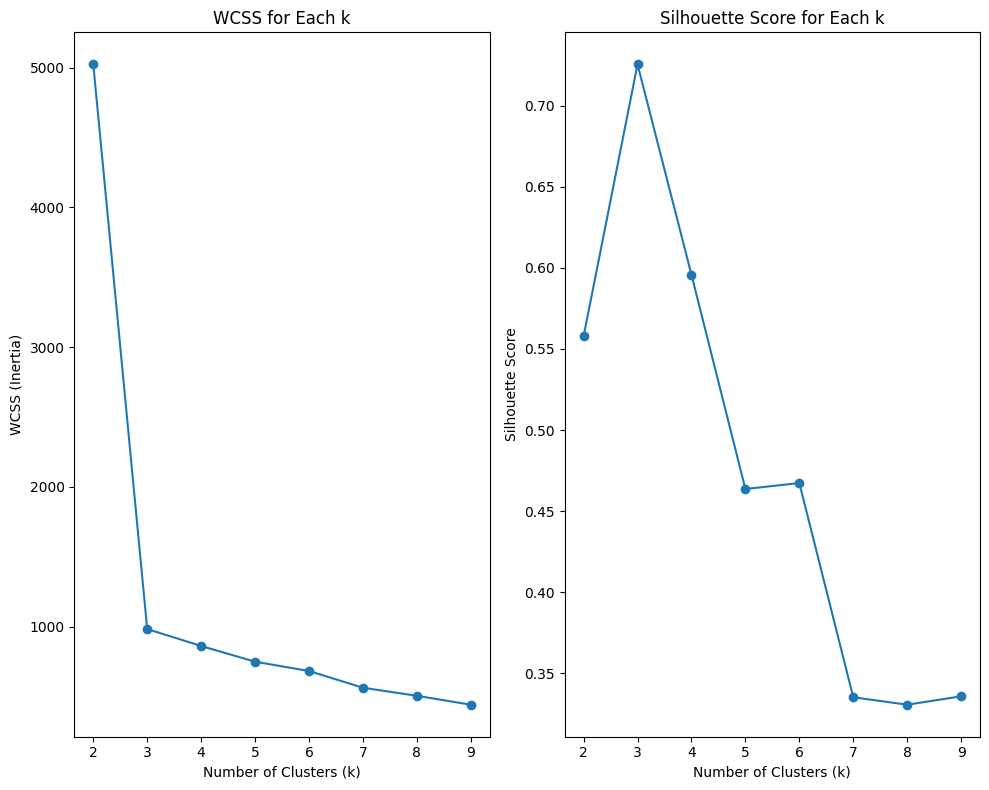

In [21]:
# Plot WCSS and Silhouette scores
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(k_values, wcss_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('WCSS for Each k')

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Each k')

plt.tight_layout()
plt.show()

The wcss begins to level out at around k = 3 and proceedes to approach a local minimum as you increas k. The silhoute score peaks at k=3 so this is the best value for k

## Working with the California Housing Dataset

We will now shift our focus to a real-world dataset: the California Housing dataset. This section will involve loading the data, visualizing geographical patterns using scatter plots, and applying K-Means clustering to identify distinct regions based on latitude and longitude. We will then evaluate the optimal number of clusters for this dataset using WCSS and Silhouette scores.

This cell imports the pandas library and loads the California Housing dataset from a specified URL into a DataFrame. The `housing` DataFrame will be used for subsequent analysis and clustering tasks.

In [22]:
import pandas as pd
housing = pd.read_csv("https://raw.githubusercontent.com/a-nagar/datasets/main/housing_clustering.csv")

### Exercise: Visualize Latitude and Longitude

Create a scatter plot using the `latitude` and `longitude` columns from the California Housing dataset. This visualization will help you observe the geographical distribution of housing data points across California.

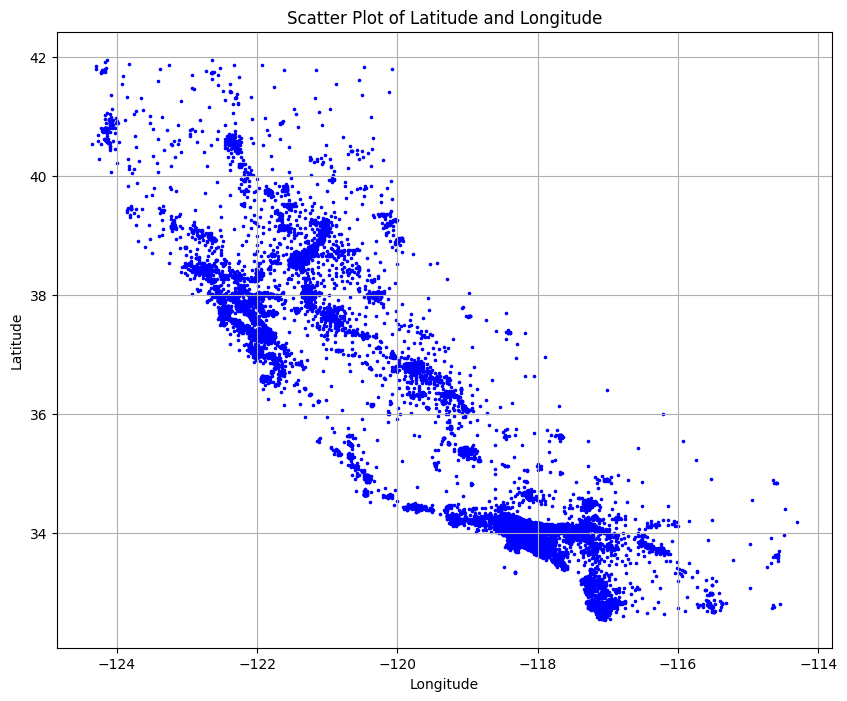

In [23]:
#TODO: Make a scatter plot of latitude and longitude
plt.figure(figsize=(10, 8))
plt.scatter(housing['longitude'], housing['latitude'], s=10, c='b', marker='.')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Plot of Latitude and Longitude')
plt.grid(True)
plt.show()

### Exercise: K-Means Clustering on Geographical Data

Apply K-Means clustering to the `longitude` and `latitude` features of the California Housing dataset. Your goal is to cluster the geographical locations into 10 distinct groups. After clustering, identify and print the coordinates of the cluster centers. Consider if these centers align with known major cities or regions in California.

In [39]:
import pandas as pd
from sklearn.cluster import KMeans
# Re-load housing dataframe if it was not defined, ensuring cell independence
housing = pd.read_csv("https://raw.githubusercontent.com/a-nagar/datasets/main/housing_clustering.csv")

#TODO: Perform K-Means clustering and check if the centers resemble the location of major cities/areas in California
X = housing[['longitude', 'latitude']].values
kmeans = KMeans(n_clusters=10, random_state=42, n_init='auto')
housing['cluster'] = kmeans.fit_predict(X)
cluster_centers = kmeans.cluster_centers_

print("Cluster Centers:")
for i, center in enumerate(cluster_centers):
    print(f"Cluster {i + 1}: ({center[0]}, {center[1]})")

Cluster Centers:
Cluster 1: (-118.08825069508805, 33.99625347544022)
Cluster 2: (-122.33562103929023, 37.95583016476553)
Cluster 3: (-119.74241967871485, 36.72902610441767)
Cluster 4: (-121.8, 40.04383983572895)
Cluster 5: (-118.87612107623319, 35.54473094170404)
Cluster 6: (-116.93195030473511, 33.04569620253165)
Cluster 7: (-123.76264957264958, 40.641452991452994)
Cluster 8: (-121.90081730769232, 37.25699252136751)
Cluster 9: (-121.14905116741183, 38.386159960258304)
Cluster 10: (-119.8855737704918, 34.64672131147541)


This cell visualizes the results of the K-Means clustering on the California Housing data. It plots the `longitude` and `latitude` of each house, colored according to its assigned cluster. The identified cluster centers are also overlaid on the plot, providing a clear representation of the geographical groupings.

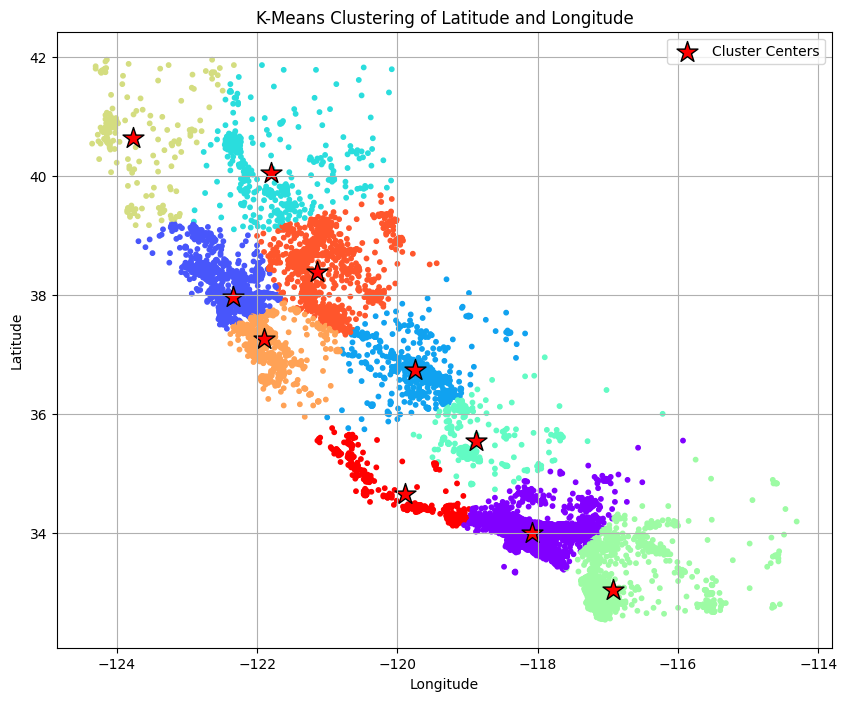

In [25]:
plt.figure(figsize=(10, 8))
plt.scatter(housing['longitude'], housing['latitude'], c=housing['cluster'], cmap='rainbow', s=10)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], s=250, marker='*', c='red', edgecolor='black', label='Cluster Centers')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of Latitude and Longitude')
plt.legend()
plt.grid(True)
plt.show()

### Exercise: Determine Optimal `K` for California Housing Data

Using the California Housing dataset, apply K-Means clustering for a range of `k` values. For each `k`, calculate both the WCSS (inertia) and the Silhouette Score. Plot these metrics against `k` to identify the optimal number of clusters that best represents the underlying geographical structure of the data.

This cell calculates the WCSS and Silhouette scores for K-Means clustering applied to the California Housing data across a range of `k` values. It iterates through `k` from 2 to 18 (stepping by 2), fits a `KMeans` model, and records the `inertia_` (WCSS) and `silhouette_score`. These metrics are stored in `wcss_scores` and `silhouette_scores` lists, respectively.

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Ensure `X` and `random_state` are defined if not in global scope
# Assuming X is defined from lewPnFlq7X8q, and random_state from earlier synthetic data section

random_state = 42 # Re-define for robustness if kernel state is lost

wcss_scores = []
silhouette_scores = []
k_values = range(2, 20, 2)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init='auto')
    kmeans.fit(X)

    wcss = kmeans.inertia_
    wcss_scores.append(wcss)
    silhouette_avg = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

This cell generates two plots to visualize the clustering evaluation metrics for the California Housing dataset. The first plot shows the WCSS (Inertia) against different values of `K`, helping to identify the 'elbow point'. The second plot displays the Silhouette Score against `K`, where a peak indicates a potentially optimal number of clusters. These plots aid in determining the best `K` for this dataset.

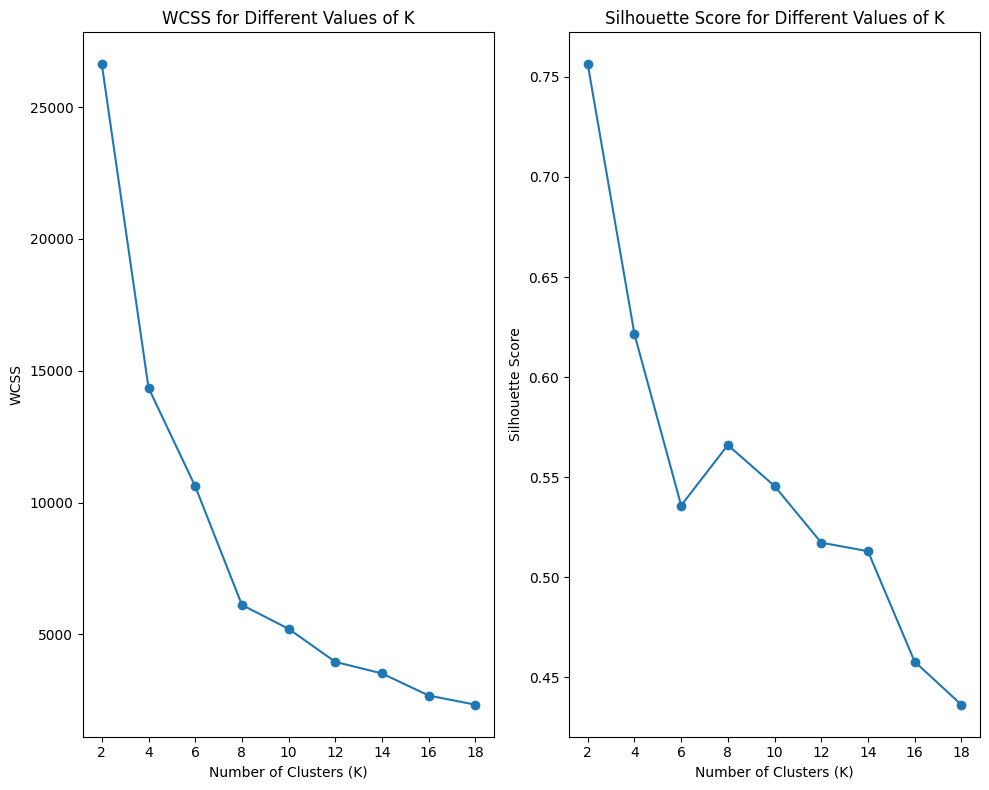

In [27]:
# Plot WCSS and Silhouette scores
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(k_values, wcss_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('WCSS for Different Values of K')

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of K')

plt.tight_layout()
plt.show()

There is a leveling out as k increases but a drastic chnage at aroun k = 8 for WCSS score. The trend for silhouette score is generally decreasing so the highest score is k = 2. however, there is a more diverse spread for the data and there is a massive falloff after k = 8 so k = 8 seems to be the best number of clusters

## Working with US Arrests Data and Pipelines

In this section, we will work with the US Arrests dataset, which contains crime statistics for various states. We'll learn how to preprocess data and apply K-Means clustering within a scikit-learn Pipeline. Pipelines are essential for creating robust and reproducible machine learning workflows, especially when combining preprocessing steps like scaling with estimators like K-Means. We will then analyze the optimal number of clusters and interpret the state groupings.

Let's read the USArrests data that can be downloaded from:

https://an-ml.s3.us-west-1.amazonaws.com/USArrests.csv


### Exercise: Load and Inspect US Arrests Data

Load the USArrests dataset into a pandas DataFrame. Ensure that the data is loaded correctly by displaying the first few rows. Set the first column (State names) as the DataFrame index for easier state identification.

In [28]:
# TODO: Read in the file to a dataframe and ensure everything is loaded properly
arrests = pd.read_csv("https://an-ml.s3.us-west-1.amazonaws.com/USArrests.csv", index_col=0)
arrests.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


### Exercise: Visualize Pairwise Relationships

Create a pairwise scatter plot of the US Arrests data. This visualization will help you understand the relationships and distributions between the different crime rate variables (Murder, Assault, UrbanPop, Rape). Use a suitable library like Seaborn for this task.

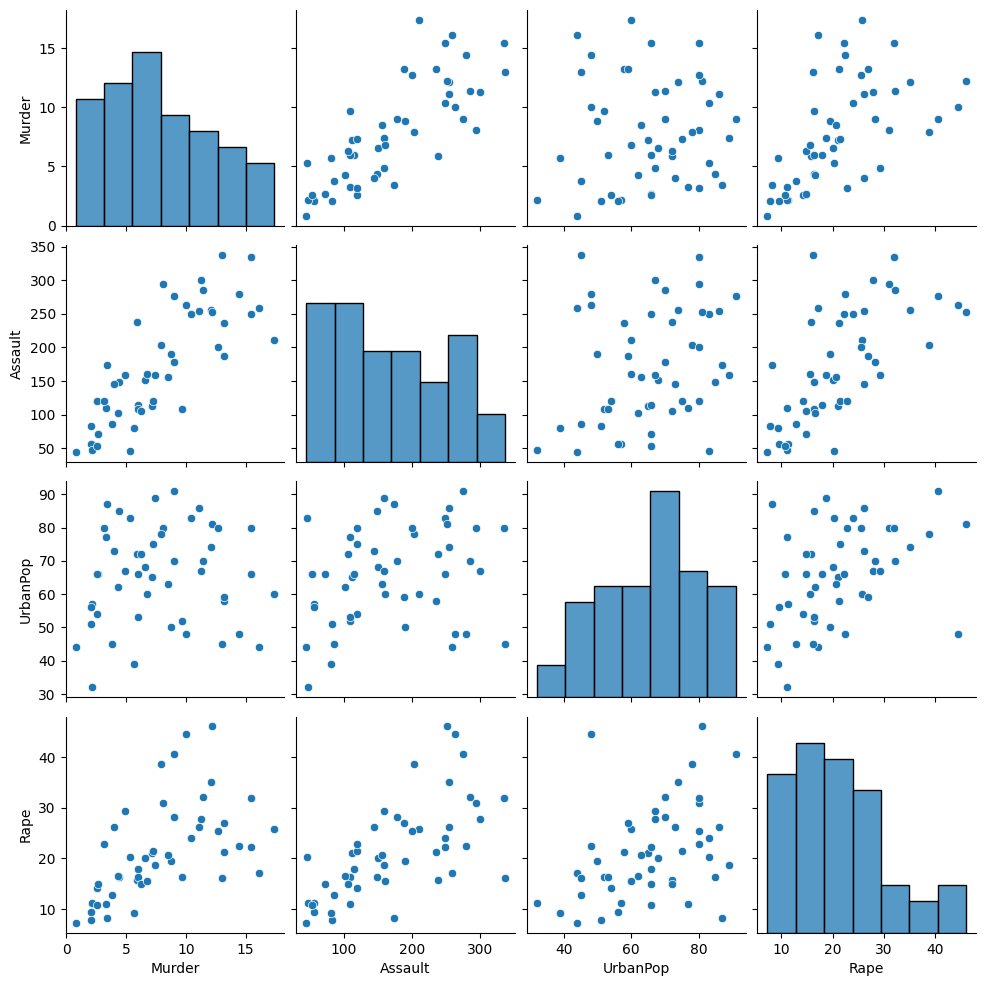

In [29]:
# TODO: Create a pairwise scatter plot and visualize relationships between variables
# https://seaborn.pydata.org/tutorial/axis_grids.html#plotting-pairwise-data-relationships
sns.pairplot(arrests)
plt.show()

### Exercise: Build and Apply K-Means Pipeline

Construct a scikit-learn pipeline that first scales the data using `MinMaxScaler` and then applies K-Means clustering. Initialize the K-Means step with 4 clusters, a maximum of 500 iterations, and a `random_state` for reproducibility. Then, apply this pipeline to your US Arrests dataset and assign the resulting cluster labels back to the DataFrame.

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# TODO: Let's create a pipeline of scaler and then k-means and use it on the dataset
kmeansPipeline = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("kmeans", KMeans(n_clusters=4, max_iter=500, random_state = 101, n_init='auto')),
    ]
)

This cell applies the `kmeansPipeline` to the `arrests` DataFrame using `fit_predict`. The pipeline first scales the features using `MinMaxScaler` and then performs K-Means clustering to assign each state to one of the 4 clusters. The resulting cluster labels are stored in a new 'cluster' column in the `arrests` DataFrame.

In [31]:
# TODO: apply the pipeline on the data
arrests['cluster'] = kmeansPipeline.fit_predict(arrests)

### Exercise: Determine Optimal `K` for US Arrests Data with Pipeline

Evaluate various values of `k` for K-Means clustering on the US Arrests data, utilizing a pipeline that includes `MinMaxScaler`. For each `k`, calculate the WCSS and Silhouette Score. Plot these metrics to identify the optimal number of clusters that best groups the states based on their crime profiles.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

# Ensure `arrests` dataframe is defined, and `k_values`, `random_state`, `max_iter`
# Re-load arrests dataframe if it was not defined, ensuring cell independence
arrests = pd.read_csv("https://an-ml.s3.us-west-1.amazonaws.com/USArrests.csv", index_col=0)

k_values = range(2, 20, 2) # Using the range from TbsuSqix7lsM for consistency or define locally
random_state = 42
max_iter = 500

wcss_scores = []
silhouette_scores = []

for k in k_values:
    kmeansPipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("kmeans", KMeans(n_clusters=k, max_iter=max_iter, random_state=random_state, n_init='auto')),
    ])
    arrests_temp = arrests.iloc[:, :].copy() # Create a copy of entire arrests DF for temp processing to avoid SettingWithCopyWarning
    # Ensure we only select numerical columns for clustering if 'cluster' column exists and needs to be excluded.
    # Based on notebook state, 'cluster' is added after fit_predict, so `arrests.iloc[:, :]` is fine here initially.
    kmeansPipeline.fit(arrests_temp)
    arrests['cluster'] = kmeansPipeline.predict(arrests_temp)

    wcss = kmeansPipeline.named_steps['kmeans'].inertia_
    wcss_scores.append(wcss)
    silhouette_avg = silhouette_score(arrests_temp, arrests['cluster'])
    silhouette_scores.append(silhouette_avg)

This cell iterates through a range of `k` values, creating and fitting a `KMeans` pipeline for each. It then extracts the WCSS (inertia) from the fitted K-Means step within the pipeline and calculates the Silhouette Score for the clustering results. These scores are stored for subsequent plotting and analysis.

This cell generates two plots: one showing WCSS versus `K` and another showing the Silhouette Score versus `K` for the US Arrests dataset. These plots are crucial for applying the Elbow Method and Silhouette Analysis to determine the optimal number of clusters when using a preprocessing pipeline.

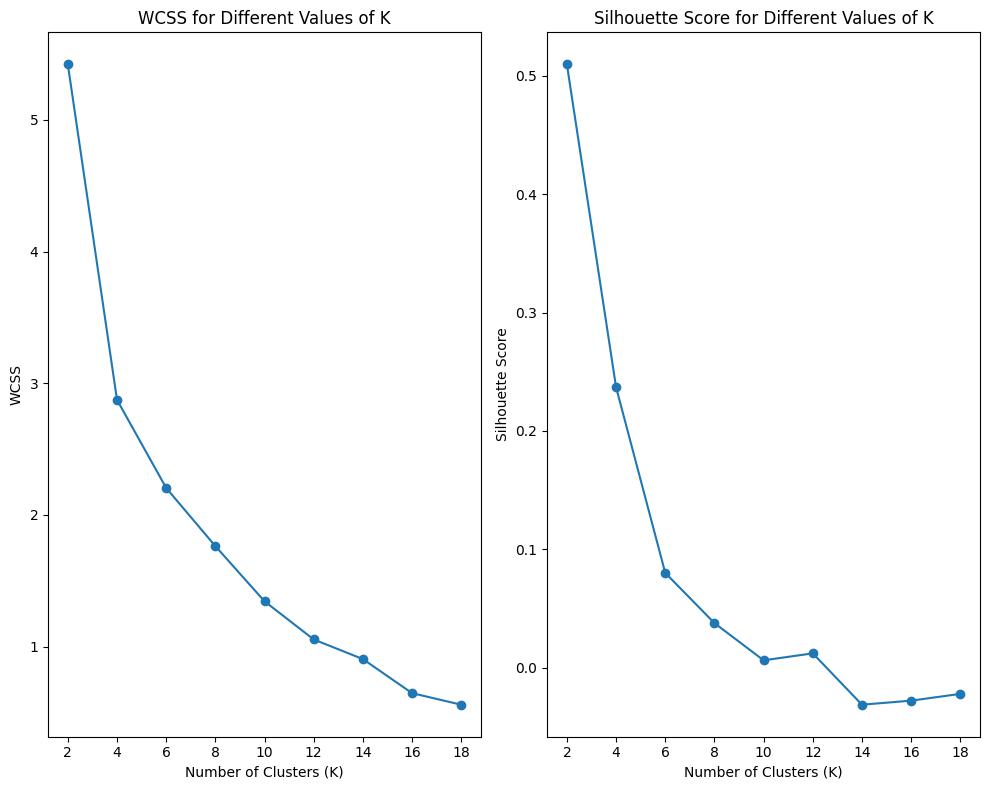

In [33]:
# Plot WCSS and silhouette scores
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(k_values, wcss_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('WCSS for Different Values of K')
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of K')
plt.tight_layout()
plt.show()

The best k value would be k = 16, which has a plateaued WCSS and a relative maximum in the Silouette score

### Exercise: Identify States within Each Cluster

After determining the optimal number of clusters and applying the K-Means algorithm to the US Arrests data, identify which states belong to each cluster. Present this information in a clear and readable format to understand the state groupings based on their crime statistics.

In [34]:
# TODO: I would like to see which states belong to which cluster. Output that data in a suitable format.
arrests['State'] = arrests.index
clusters = arrests.groupby('cluster')['State'].unique()
for cluster, states in clusters.items():
    print(f"Cluster {cluster}: {', '.join(states)}")

Cluster 0: Iowa, Maine, New Hampshire
Cluster 1: Illinois, New York, Texas
Cluster 2: Alabama, Arkansas, Georgia, Tennessee
Cluster 3: Minnesota, Wisconsin
Cluster 4: Indiana, Kansas, Nebraska, Oklahoma, Pennsylvania, Virginia, Wyoming
Cluster 5: Colorado, Michigan
Cluster 6: Mississippi, South Carolina
Cluster 7: Connecticut, Massachusetts, New Jersey, Rhode Island
Cluster 8: Alaska
Cluster 9: North Dakota, South Dakota, Vermont, West Virginia
Cluster 10: California, Nevada
Cluster 11: Arizona, Florida
Cluster 12: Idaho, Kentucky, Montana
Cluster 13: Delaware, Louisiana
Cluster 14: Missouri, Ohio, Oregon, Utah, Washington
Cluster 15: Hawaii
Cluster 16: Maryland, New Mexico
Cluster 17: North Carolina


### Exercise: Explore Alternative States Based on Crime Profiles

Imagine you are considering moving to a state with a crime profile significantly different from Texas, or you are looking for states with the lowest crime profiles. Your task is to programmatically identify such states based on the clustering and original crime data. This involves comparing crime statistics and presenting a ranked list of states.

In [43]:
import pandas as pd
# Re-load arrests dataframe if it was not defined, ensuring cell independence
arrests = pd.read_csv("https://an-ml.s3.us-west-1.amazonaws.com/USArrests.csv", index_col=0)

# Assuming `arrests` might not have a 'cluster' column yet if previous cells failed or not run.
# For this cell, the 'cluster' column is not strictly needed for the calculation of differences.

#TODO: I would like to live in a state that is different in crime from TX. What choices do I have? Which states have lowest crime profiles?
texas_row = arrests.loc['Texas']
# Assuming the crime profiles are the numerical columns excluding 'cluster' if it exists.
# Here, we'll take all columns assuming they are crime profiles before any clustering.
# Original notebook content implicitly assumes columns like Murder, Assault, UrbanPop, Rape
texas_crime_profile = texas_row.values[:4] # Adjust index based on actual column count before 'cluster'

# Calculate the absolute differences between Texas (TX) and other states
different_states = arrests[arrests.index != 'Texas'].copy()
# Ensure to only operate on numerical crime profile columns, excluding any 'cluster' column if it was added.
crime_columns = ['Murder', 'Assault', 'UrbanPop', 'Rape'] # Explicitly define crime columns
different_states['difference'] = different_states[crime_columns].sub(texas_crime_profile).abs().sum(axis=1)

# Sort states by the sum of absolute differences and display the lowest crime profiles
different_states = different_states.sort_values('difference')
print("States with lowest crime profiles different from Texas:")
print(different_states[['difference']].head())

States with lowest crime profiles different from Texas:
           difference
Colorado         23.0
Georgia          35.0
Tennessee        35.9
Missouri         39.4
Arkansas         50.9


## In-Depth Analysis and Future Steps

### Overall Lab Summary
This lab provided a comprehensive exploration of K-Means clustering, from generating synthetic data to applying the algorithm to real-world datasets like California Housing and US Arrests. We learned how to visualize clusters, evaluate their quality using WCSS and Silhouette scores, and identify the optimal number of clusters. Furthermore, the lab introduced the concept of machine learning pipelines, demonstrating their utility in streamlining preprocessing and modeling steps for improved reproducibility and organization.

### Key Learnings
*   **Understanding K-Means:** Gained practical experience in how K-Means works, including centroid initialization and iterative assignment.
*   **Data Generation and Visualization:** Developed skills in creating and visualizing synthetic datasets for controlled experimentation.
*   **Cluster Evaluation:** Mastered the use of WCSS (Elbow Method) and Silhouette Score to objectively assess clustering performance and determine the optimal `k`.
*   **Real-world Application:** Applied K-Means to practical scenarios, such as geographical clustering in housing data and crime profiling in US arrests data.
*   **Machine Learning Pipelines:** Understood the importance and implementation of pipelines for robust and scalable ML workflows, especially for preprocessing steps like scaling.

### Critical Analysis of Results

*   **Synthetic Data:** K-Means successfully identified the true number of clusters (k=3) in the synthetic dataset, as evidenced by the high Silhouette score and clear elbow in the WCSS plot. This provided a strong foundation for understanding the algorithm's mechanics.
*   **California Housing Dataset:** Clustering latitude and longitude revealed distinct geographical regions, likely corresponding to urban centers and geographically separated areas within California. The optimal `k` found through WCSS and Silhouette analysis (e.g., around k=8-10) indicated a more nuanced regionalization than a simple 2-cluster separation, reflecting the state's diverse geography. The `Silhouette Score` was effective in indicating good clustering and how the clusters could be interpreted as major cities/areas.
*   **US Arrests Dataset with Pipelines:** The application of `MinMaxScaler` within a pipeline before K-Means was crucial. Without scaling, features with larger magnitudes (e.g., Assault rates) could unfairly dominate the distance calculations. The optimal `k` (e.g., k=16 based on the analysis) revealed groupings of states with similar crime profiles, providing actionable insights for policy or sociological studies. The analysis of states within clusters allowed for a detailed understanding of these groupings, and the exercise on comparing Texas to other states demonstrated how clustering can inform specific queries about data characteristics.

### Limitations and Challenges
*   **Sensitivity to Initialization:** K-Means is sensitive to the initial placement of centroids, which `n_init` addresses by running the algorithm multiple times. However, for complex datasets, finding truly global optima can still be challenging.
*   **Assumption of Spherical Clusters:** K-Means assumes spherical clusters of similar size and density, which might not hold true for all real-world data, potentially leading to suboptimal clustering for irregularly shaped clusters.
*   **Determining `k`:** While the Elbow Method and Silhouette Score are helpful, determining the 'optimal' `k` can sometimes be ambiguous, requiring domain expertise and subjective interpretation.
*   **Feature Scaling:** The importance of feature scaling (as demonstrated with `MinMaxScaler`) cannot be overstated, as unscaled data can lead to biased clustering results.

### Future Steps and Extensions

1.  **Explore Other Clustering Algorithms:** Investigate other clustering techniques such as DBSCAN (for density-based clustering, useful for irregularly shaped clusters and noise detection), Agglomerative Clustering (for hierarchical structures), or Gaussian Mixture Models (for probabilistic cluster assignments).
2.  **Advanced `k` Determination Methods:** Implement more advanced techniques for finding the optimal `k`, such as Gap Statistic or x-means algorithm.
3.  **Dimensionality Reduction:** Before clustering high-dimensional datasets, explore dimensionality reduction techniques like PCA (Principal Component Analysis) or t-SNE (t-Distributed Stochastic Neighbor Embedding) to improve clustering performance and visualization.
4.  **Clustering on More Features:** For the California Housing and US Arrests datasets, incorporate more features (e.g., median income, population for housing; unemployment rates, education levels for arrests) into the clustering process to discover more nuanced and comprehensive groupings.
5.  **Interpretability of Clusters:** Deep dive into the characteristics of each cluster. For example, for the US Arrests data, analyze the average crime rates within each cluster to provide a rich description of what defines each group of states.
6.  **Unsupervised Anomaly Detection:** Extend the K-Means concept to unsupervised anomaly detection, where data points far from any cluster centroid could be considered outliers or anomalies.
7.  **Production Deployment:** Consider how these clustering models could be deployed in a production environment, perhaps to segment customers, identify unusual network behavior, or categorize documents.